# Github Notebook Link

https://github.com/neerapatel5/ML-fundamentals-2026.git

In [1]:
## cd ~/ML-fundamentals-2026

import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder


print("Kernel working")
print("Working directory:", os.getcwd())

Kernel working
Working directory: /Users/neerapatel/ML-fundamentals-2026


# Ordering and Pipeline Design

Task 1: Identifying the Prediction Target
- I will first identify which variable should be predicted.
- At this stage, I will only inspect the dataset structure and problem context.
- I will avoid using any information derived from modeling or evaluation results.

Task 2: Data Loading and Exploration
- I will load the dataset and explore its structure, variable types, and distributions.
- I can use the full dataset for general inspection since no transformations are being fitted yet.
- However, I will avoid computing statistics that will later be used for preprocessing decisions.

Task 3: Data Splitting
- I will split the dataset into training, validation, and test sets.
- This step must happen early so that all later transformations learn only from the training data.
- If splitting were done later, statistics such as scaling parameters or category frequencies could leak information from validation or test sets.

Task 4: Managing Missing Values
- I will identify explicit and implicit missing values.
- Any imputation strategy will be fitted using only the training set and then applied to validation and test sets.
- Using the full dataset here could introduce leakage through shared statistics.

Task 5: Encoding Categorical Variables
- I will convert categorical variables into numerical representations suitable for modeling.
- Encoders will be fitted on the training data and then applied to validation and test sets to ensure consistent transformations.

Task 6: Feature Scaling
- I will scale numerical variables using statistics learned from the training set.
- Validation and test data will only be transformed using those learned parameters.

Task 7: Feature Selection
- I will remove features with low variance or high correlation using only the training data.
- Performing feature selection on the full dataset could allow the model to indirectly learn patterns from validation or test sets.

Task 8: Addressing Class Imbalance
- I will apply resampling (e.g., SMOTE) only to the training data.
- Applying resampling before splitting would cause synthetic or duplicated observations to appear across dataset splits, creating leakage.

Task 9: Training a Logistic Regression Model
- Finally, I will train the model on the processed training data and evaluate its performance using the validation set.
- The validation and test sets will remain untouched by training procedures to ensure an unbiased evaluation.

An example of incorrect ordering would be applying preprocessing steps such as feature scaling or SMOTE before splitting the dataset into training, validation, and test sets. If scaling were done on the full dataset, the statistics used for scaling would include information from the validation and test sets, indirectly leaking future data into the training process. In a similar fashion, applying SMOTE before splitting could cause synthetic samples derived from the same observation to appear in multiple dataset splits. In both cases, the model would be evaluated on data that influenced the training process and would predict incorrectly.

## Task 1: Identifying the Prediction Target 

The prediction target is y, which indicates whether the client subscribed to a term deposit (“yes”/“no”). This matches the campaign’s goal, which is predicting who will subscribe so future outreach can be targeted more efficiently.

Two variables that might look like targets but are not:
- duration: call length is only known after the call, so using it would leak future information.

- campaign: number of contacts is campaign process behavior, not the conversion outcome the bank cares about.

## Task 2: Data Loading and Exploration

In [2]:
data_path = "bank-additional-full.csv" 
df = pd.read_csv(data_path, sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print(df.shape)
df.info()
df.describe().T

(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   411

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [4]:
## identify numerical vs. categorical
## target distribution & class imbalance

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Numerical variables:", num_cols)
print("Categorical variables:", cat_cols)

df["y"].value_counts()
df["y"].value_counts(normalize=True)


Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

The target variable is imbalanced, with a substantially larger proportion of clients who did not subscribe compared to those who did. This imbalance may bias the model toward predicting the majority class. As a result, evaluation metrics such as precision and recall will be more informative than accuracy alone.

In [5]:
## missing values 

df.isnull().sum().sort_values(ascending=False)

implicit_missing = {}
for col in cat_cols:
    implicit_missing[col] = (df[col] == "unknown").sum()

pd.Series(implicit_missing).sort_values(ascending=False)

default        8597
education      1731
housing         990
loan            990
job             330
marital          80
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

There are no explicit missing values. However, several categorical variables contain a meaningful number of “unknown” entries. These may represent missing or unavailable information rather than valid categories.

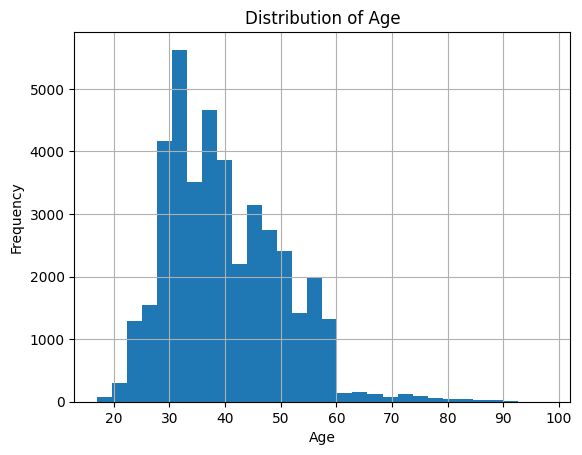

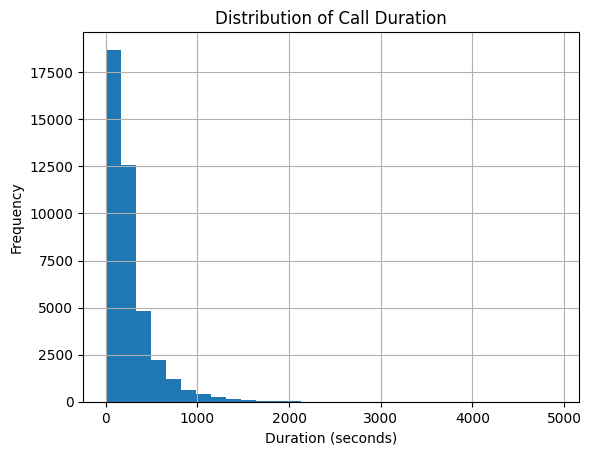

In [6]:
## numerical visualize

## age distribution
df["age"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## duration distribution
df["duration"].hist(bins=30)
plt.title("Distribution of Call Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

The distribution for age is pretty concentrated in the mid-adult range (30-40). This could suggest that the bank may target people who are a bit more financially stable and have young families. This is likely when people are getting married or are beginning to invest their money.

The duration variable is very skewed, showing shorter calls. This pattern suggests that extended interactions may be associated with stronger customer engagement. 

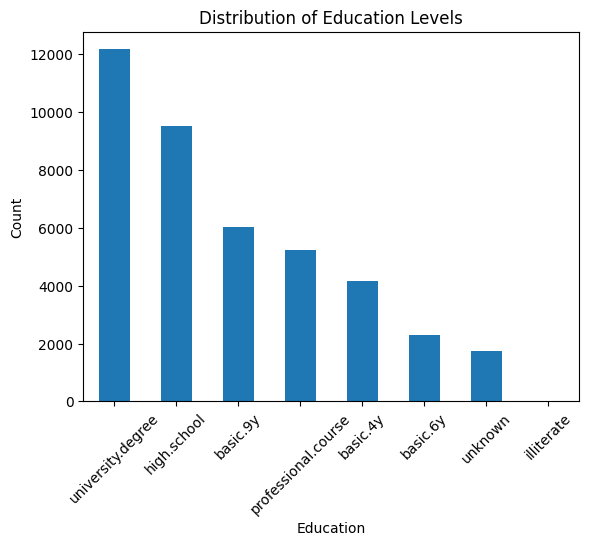

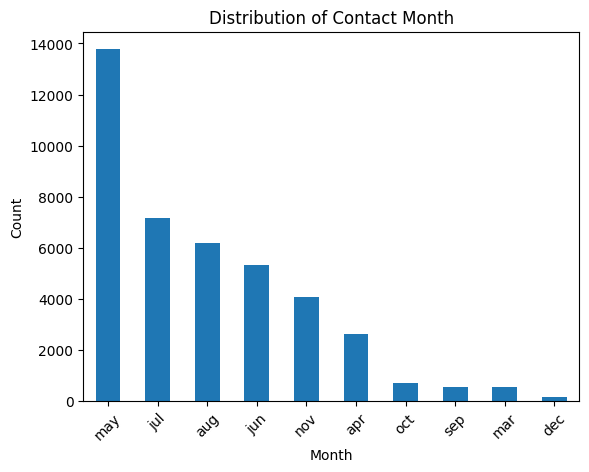

In [7]:
## categorical visualization

## education distribution
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Levels")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## month distribution
df["month"].value_counts().plot(kind="bar")
plt.title("Distribution of Contact Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The distribution of contact month shows that most outreach happens in the late spring and summer, especially in May, July, and August. This could suggest that the bank is strategically targeting customers during times when they may be more financially active or responsive, such as after tax season or during mid-year financial planning. 

The education distribution is heavily concentrated in university degree and high school categories. This suggests that the campaign is reaching a fairly broad but still relatively educated customer base. Education may be an important factor because individuals with higher levels of education could be more comfortable with financial products or long-term investments. It is important to note that there is also a good portion of “unknown” values, which likely represent missing or unavailable information rather than a meaningful category. 

One variable that needs special consideration is duration, which measures how long the last call lasted. While this is likely very predictive, it is only known after the call has already happened. Since the goal is to predict subscription before or during the contact decision, using duration would introduce data leakage and lead to unrealistic model performance. Because of this, it will likely need to be excluded from the final model.


# Task 3: Data Splitting

In [8]:
## define x and y 

X = df.drop(columns=["y"]).copy()
y = df["y"].map({"no": 0, "yes": 1}).astype(int)

print("X shape:", X.shape)
print("y mean (yes-rate):", y.mean())


X shape: (41188, 20)
y mean (yes-rate): 0.11265417111780131


In [9]:
## split + sanity check

## first split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## second split: temporary into validation and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

## check size
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

## check class balance
print("\nYes-rate:")
print("Overall:", y.mean())
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Train: (32950, 20)
Validation: (4119, 20)
Test: (4119, 20)

Yes-rate:
Overall: 0.11265417111780131
Train: 0.11265553869499241
Validation: 0.11264870114105366
Test: 0.11264870114105366


I split the dataset into training, validation, and test sets before preprocessing. This helps prevent data leakage, since steps like encoding, scaling, or feature engineering should only be learned from the training data. If these were done before splitting, the model would use information from the validation and test sets, which would lead to overly positive results.

An 80/10/10 split was used so that most of the data is available for training, while still keeping separate validation and test sets. The validation set will be used for model and pipeline decisions, and the test set will remain untouched for the final evaluation.
 I used stratified sampling because the target variable is imbalanced, with fewer clients subscribing than not. This keeps the class proportions similar across each split and makes evaluation more reliable.

# Task 4: Managing Missing Values

In [10]:
## explicit missing values (NaN) in training data

missing_explicit = X_train.isna().sum().sort_values(ascending=False)
missing_explicit[missing_explicit > 0]

Series([], dtype: int64)

In [11]:
## show implicit missing values ("unknown") in categorical features
implicit_missing = {}

for col in X_train.select_dtypes(include="object").columns:
    implicit_missing[col] = (X_train[col] == "unknown").sum()

pd.Series(implicit_missing).sort_values(ascending=False)

default        6940
education      1397
housing         796
loan            796
job             265
marital          65
contact           0
month             0
day_of_week       0
poutcome          0
dtype: int64

In [12]:
## find percentage of implicit missing values
implicit_pct = {}

for col in X_train.select_dtypes(include="object").columns:
    implicit_pct[col] = (X_train[col] == "unknown").mean()

pd.Series(implicit_pct).sort_values(ascending=False)

default        0.210622
education      0.042398
housing        0.024158
loan           0.024158
job            0.008042
marital        0.001973
contact        0.000000
month          0.000000
day_of_week    0.000000
poutcome       0.000000
dtype: float64

Missing values were analyzed using only the training data to avoid any kind of data leakage. This is important because any imputation or transformation that learns patterns from the full dataset could introduce information from the validation or test sets. As discussed in the lectures, preprocessing steps should only be run on the training data and then later applied to the other splits.

The dataset contains very few explicit missing values in the form of NaN. However, several categorical variables contain implicit missing values represented as “unknown.” These likely reflect unavailable or unrecorded information rather than meaningful categories. The extent of missingness varies across features, with some variables having only a small proportion of unknown values and others having a more noticeable share. 

For categorical variables, the main strategy will be to treat “unknown” as a separate category rather than imputing. I am choosing this approach because the absence of information could potentially have a predictive value. For example, not reporting employment or education could be related to financial behavior or engagement with the bank. I considered replacing “unknown” with the most frequent category. However, I decided not to because it assumes that missing values behave similarly to the majority group, which may not be true and could mess up the distribution of the data. For numerical variables, if missing values appear later, imputation using the median or similar stats would be used. Median imputation is robust to skewed distributions and works with logistic regression. These statistics would be computed only on the training data and then applied to the validation and test sets.

My strategy separates data cleaning decisions from modeling decisions. Cleaning focuses on identifying true missing or inconsistent entries, while modeling considers whether missingness itself may carry useful predictive information.

# Task 5: Encoding Categorical Variables\

In [13]:
## separate categorical variables
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Categorical variables:")
print(cat_cols)

## education as ordinal, rest as nominal
ordinal_cols = ["education"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols]

print("Ordinal:", ordinal_cols)
print("Nominal:", nominal_cols)


Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Ordinal: ['education']
Nominal: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [14]:
## show what education levels there are
sorted(df["education"].unique())

['basic.4y',
 'basic.6y',
 'basic.9y',
 'high.school',
 'illiterate',
 'professional.course',
 'university.degree',
 'unknown']

In [15]:
## define order of education

edu_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'unknown']
ordinal_encoder = OrdinalEncoder(categories=[edu_order])

In [16]:
## fit training only (ordinal)
X_train_ord = ordinal_encoder.fit_transform(X_train[ordinal_cols])

## validation AND test (ordinal)
X_val_ord = ordinal_encoder.transform(X_val[ordinal_cols])
X_test_ord = ordinal_encoder.transform(X_test[ordinal_cols])

In [17]:
## define onehot
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

## fit only on training (nominal)
X_train_nom = onehot_encoder.fit_transform(X_train[nominal_cols])

## apply to validation and test (nominal)
X_val_nom = onehot_encoder.transform(X_val[nominal_cols])
X_test_nom = onehot_encoder.transform(X_test[nominal_cols])

In [18]:
## ORDINAL DF
X_train_ord = pd.DataFrame(X_train_ord, columns=ordinal_cols, index=X_train.index)
X_val_ord = pd.DataFrame(X_val_ord, columns=ordinal_cols, index=X_val.index)
X_test_ord = pd.DataFrame(X_test_ord, columns=ordinal_cols, index=X_test.index)

## NOMINAL DF
nominal_feature_names = onehot_encoder.get_feature_names_out(nominal_cols)
X_train_nom = pd.DataFrame(X_train_nom, columns=nominal_feature_names, index=X_train.index)
X_val_nom = pd.DataFrame(X_val_nom, columns=nominal_feature_names, index=X_val.index)
X_test_nom = pd.DataFrame(X_test_nom, columns=nominal_feature_names, index=X_test.index)

## combine them togther
X_train_encoded = pd.concat([X_train_ord, X_train_nom], axis=1)
X_val_encoded = pd.concat([X_val_ord, X_val_nom], axis=1)
X_test_encoded = pd.concat([X_test_ord, X_test_nom], axis=1)

print("Encoded training shape:", X_train_encoded.shape)

Encoded training shape: (32950, 46)


I converted the categorical variables into numerical variables so that the model was able to train them. I am treating education as ordinal because the level of education is linear. This means that the model can predict any progression between the variables because education is not just a category. 

The rest of the variables were treated as nominal categories and I used one-hot encoding. This helps to minimize any bias and helps it become easier for the model to interpret, as the categories now have coefficients. 

The encoders were fitted on the training data and then applied to both the validation and test sets that I split up. This is crucial because encoding learns patterns from the data, such as which categories exist. If I fitted the encoders on the full dataset, it could introduce data leakage and make the model performance look better than it really is. 

Encoding increases the dimensionality of the dataset because one-hot encoding creates a separate feature for each category, especially for variables like job or month with many levels. While this makes the model more complex, it also improves interpretability since each category has its own coefficient, making it easier to understand how different customer groups relate to the probability of subscription. Treating education as ordinal also helps because the coefficient reflects a meaningful progression rather than unrelated categories. Finally, encoding changes the types of decision boundaries a linear model can represent. Even though the model is still linear, one-hot encoding allows it to separate categories more flexibly, while ordinal encoding allows it to capture ordered trends.

# Task 6: Feature Scaling

In [19]:
## identify numerical variables 
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numerical variables:")
print(num_cols)

Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [20]:
scaler = StandardScaler()

## fit on training data
X_train_scaled = scaler.fit_transform(X_train[num_cols])

## apply to validation and test set
X_val_scaled = scaler.transform(X_val[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

In [21]:
# convert to df
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_cols, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=num_cols, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_cols, index=X_test.index)

print(X_train_scaled.head())

            age  duration  campaign     pdays  previous  emp.var.rate  \
25611  0.863739 -0.120196  0.522981  0.196584 -0.350127     -0.114858   
26010 -0.289722 -0.216732 -0.203688  0.196584  1.653813     -0.114858   
40194  3.651268  3.436173 -0.567023  0.196584 -0.350127     -1.133161   
297   -0.385843 -0.533368 -0.203688  0.196584 -0.350127      0.648868   
36344  1.824956  0.424264 -0.203688  0.196584 -0.350127     -1.896888   

       cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
25611       -0.648967      -0.322269   0.288964     0.398990  
26010       -0.648967      -0.322269   0.288964     0.398990  
40194        1.103451       0.045048  -1.583296    -2.420139  
297          0.721890       0.887717   0.713535     0.332723  
36344       -1.058152      -0.062987  -1.357472    -1.252175  


In this step, I scaled the numerical variables using standardization so that each feature has a mean of zero and a standard deviation of one. I chose this method because logistic regression is sensitive to the scale of the inputs. If features are on very different scales, the model may train too slowly or give too much importance to variables with larger values. Scaling helps gradient-based optimization converge faster and makes the coefficients more comparable across features. It also ensures that regularization penalties are applied more consistently.

The scaler was fitted only on the training data and then applied to the validation and test sets. This prevents data leakage, since using the full dataset would allow information from future data to influence the model. A common mistake is scaling before splitting or fitting the scaler separately on each split, which leads to inconsistent transformations. By fitting once on the training set and applying the same transformation to the other sets, I ensured that the pipeline remains realistic and stable.

# Task 7: Feature Selection

In [22]:
## apply on training data
selector = VarianceThreshold(threshold=0.01)

X_train_fs = selector.fit_transform(X_train_encoded)
X_val_fs = selector.transform(X_val_encoded)
X_test_fs = selector.transform(X_test_encoded)

print("Original shape:", X_train_encoded.shape)
print("After low variance filter:", X_train_fs.shape)

Original shape: (32950, 46)
After low variance filter: (32950, 42)


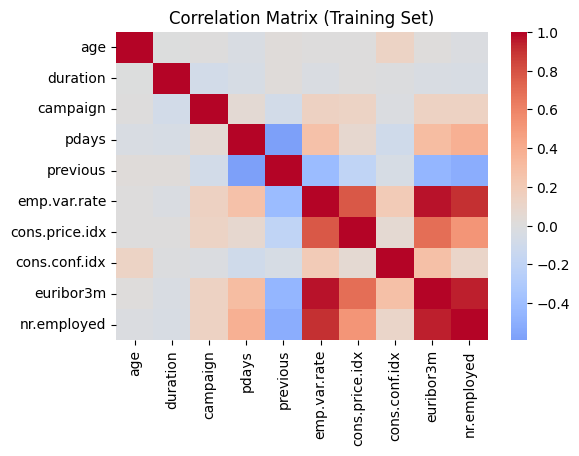

In [23]:
## identify numerical columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

corr_matrix = X_train[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Training Set)")
plt.show()

I examined the correlation matrix of the numerical variables to check for potential multicollinearity. Some macroeconomic variables such as emp.var.rate, euribor3m, and nr.employed show relatively strong correlations with each other, which is expected since they all reflect broader economic conditions. High multicollinearity can make logistic regression coefficients less stable and harder to interpret. However, because these variables capture slightly different aspects of the economic environment, I chose to retain them while noting that their effects may partially overlap.

In [24]:
## correlation matrix on training set
correlation_matrix = X_train_scaled.corr().abs()

## upper triangle
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
threshold = 0.9

drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]

print("Highly correlated features:", drop_cols)

## drop columns from all splits
X_train_scaled = X_train_scaled.drop(columns=drop_cols)
X_val_scaled = X_val_scaled.drop(columns=drop_cols)
X_test_scaled = X_test_scaled.drop(columns=drop_cols)

Highly correlated features: ['euribor3m', 'nr.employed']


In this step, I removed features that were unlikely to improve the model. First, I filtered out very low variance features using a threshold of 0.01, since variables that rarely change do not add much useful information and can increase model complexity. I also checked for highly correlated numerical variables and removed those above a correlation threshold of 0.9. This helps improve the stability of logistic regression because highly correlated features can make coefficient estimates unreliable.

I also considered conceptual factors. For example, the variable "duration" is very predictive but would not be available at prediction time, which could lead to data leakage. All feature selection was done using only the training set to avoid learning patterns from the validation or test data. Performing feature selection before splitting would reduce the model’s ability to generalize and would predict more positively.

# Task 8: Addressing Class Imbalance

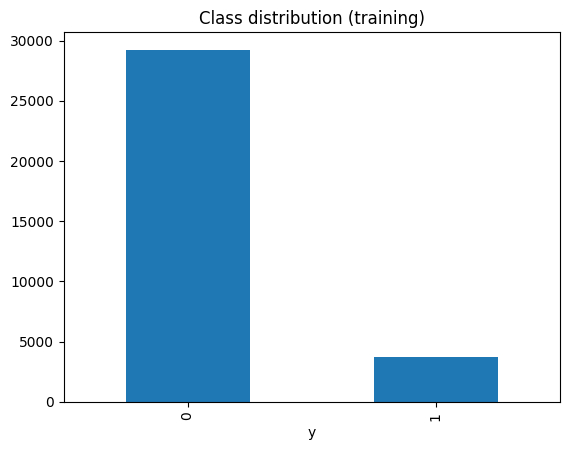

In [25]:
## check class imbalance in training set
y_train.value_counts(normalize=True)
y_train.value_counts().plot(kind="bar", title="Class distribution (training)")
plt.show()

In [26]:
smote = SMOTE(random_state=42)

## only training data
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_res.value_counts())

Before: y
0    29238
1     3712
Name: count, dtype: int64
After: y
0    29238
1    29238
Name: count, dtype: int64


In the training set, the target variable is clearly imbalanced. There are **29,238 observations in class 0** and **3,712 in class 1**, meaning the positive class represents only a small portion of the data. This imbalance matters because a model could achieve high accuracy by simply predicting the majority class most of the time, while still failing to correctly identify clients who actually subscribe.

I chose to apply SMOTE (Synthetic Minority Oversampling Technique) to the training data. SMOTE creates synthetic examples of the minority class instead of duplicating already existing observations. This helps the model learn a more balanced decision boundary. Resampling is applied after preprocessing but only on the training set, since it is part of the training procedure. The validation and test sets must keep the original distribution so they reflect the real data. SMOTE assumes that new minority examples can be created by interpolating between similar observations. This can help the learning algorithm better detect patterns associated with the minority class without heavily overfitting duplicated points.

If I conducted resampling before splitting the dataset, synthetic or duplicated examples could appear in both the training and evaluation sets. This would create problems like data leakage and lead to an inaccurate positive performance. Finally, class imbalance affects evaluation metrics; accuracy can be misleading because predicting the majority class often still gives a high score. Hence, metrics like precision and recall are more informative for evaluating how well the model interacts with the minority class.

# Task 9: Training a Logistic Regression Model


In [27]:
## train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

## predict on validation set
y_val_pred = model.predict(X_val_scaled)

Accuracy: 0.8480213644088371
Precision: 0.4166666666666667
Recall: 0.8728448275862069
Zero Rule Accuracy: 0.8873512988589464


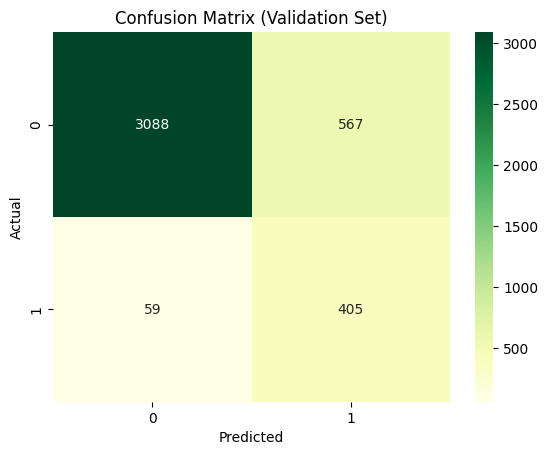

In [28]:
## heatmap metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Zero Rule Accuracy:", y_val.value_counts(normalize=True).max())

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn")
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows how the model performs across both classes. The model correctly identifies 405 clients who subscribed and 3088 who did not, indicating that it captures most positive cases while still correctly classifying many negatives. There are 567 false positives, meaning some clients are predicted to subscribe when they actually do not.

This pattern reflects the effect of addressing class imbalance with SMOTE. The model prioritizes identifying the minority class, resulting in high recall (0.87) but lower precision. In this context, this tradeoff is worth it because it could be more costly to miss potential subscribers than to contact additional non-subscribers.

In [29]:
zero_rule = y_train.value_counts(normalize=True).max()
results = pd.DataFrame({
    "Model": ["Zero Rule Baseline", "Logistic Regression"],
    "Accuracy": [zero_rule, accuracy],
    "Precision": [None, precision],
    "Recall": [None, recall]
})
results

,Model,Accuracy,Precision,Recall
0,Zero Rule Baseline,0.887344,NaN,NaN
1,Logistic Regression,0.848021,0.416667,0.872845


The Zero Rule baseline achieves higher accuracy because it always predicts the majority class. Since most clients do not subscribe, this simple rule performs well on accuracy alone but **completely fails to identify subscribers**. The logistic regression model has a slightly lower accuracy, but it is able to detect the minority class effectively. The high recall (0.87) shows that the model identifies most subscribers, while precision indicates that some predicted positives are incorrect. However, this does mean that the model is learning meaningful patterns rather than just going off the majority.

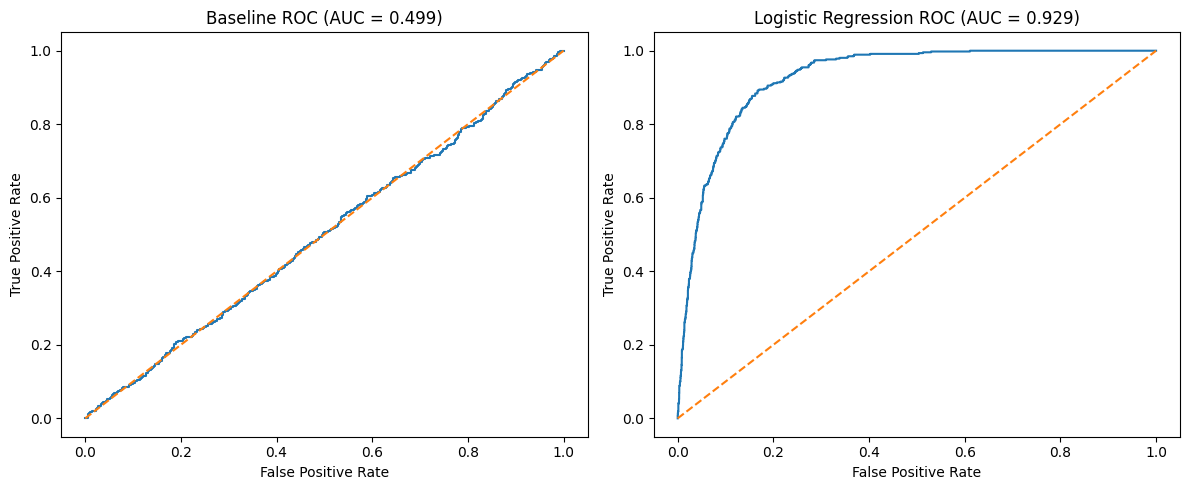

In [30]:
## lr probabilities
y_val_prob = model.predict_proba(X_val_scaled)[:,1]

## ROC lr
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_prob)
auc_lr = roc_auc_score(y_val, y_val_prob)

## baseline (random guessing)
random_probs = np.random.uniform(0,1,len(y_val))
fpr_base, tpr_base, _ = roc_curve(y_val, random_probs)
auc_base = roc_auc_score(y_val, random_probs)
fig, axes = plt.subplots(1,2, figsize=(12,5))

## baseline plot
axes[0].plot(fpr_base, tpr_base)
axes[0].plot([0,1],[0,1],'--')
axes[0].set_title(f"Baseline ROC (AUC = {auc_base:.3f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

## LR plot
axes[1].plot(fpr_lr, tpr_lr)
axes[1].plot([0,1],[0,1],'--')
axes[1].set_title(f"Logistic Regression ROC (AUC = {auc_lr:.3f})")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

plt.tight_layout()
plt.show()

The side-by-side ROC curves show a clear improvement from the baseline model to the trained logistic regression model. The baseline ROC has an AUC of 0.496, which is essentially random guessing, since the curve follows the diagonal line. In contrast, the logistic regression model achieves an AUC of 0.929, meaning it can distinguish between subscribers and non-subscribers very well. The steep curve near the top-left corner shows that the model can achieve high true positive rates while keeping false positives relatively low.

I trained an LR model to predict whether a client subscribes to a term deposit. Logistic regression works well here because it produces interpretable coefficients and lets us see how different client features influence the probability of subscribing. After encoding categorical variables, scaling numerical features, and removing low-information variables, I trained the model on the processed training data and evaluated it on the validation set. The model’s accuracy (0.848) is slightly lower than the Zero Rule baseline, but unlike the baseline, it is actually able to identify subscribers.

Because the dataset is heavily imbalanced, I applied SMOTE to the training data so the model would see more examples of the minority class. This helps prevent the model from simply predicting the majority outcome. As a result, the model achieves a high recall (0.87), meaning it correctly identifies most subscribers. Precision is lower because there are more false positives, but in a marketing context this tradeoff is reasonable since contacting a few extra clients is less costly than missing potential subscribers.

Throughout the pipeline, I also considered several potential pitfalls. The dataset contains implicit missing values, such as unknown categories, which I handled explicitly during preprocessing. I also examined multicollinearity between numerical variables (economic factors) to avoid redundant features that could destabilize a linear model. Most importantly, the workflow was designed to prevent data leakage: the dataset was split early, and preprocessing steps such as encoding, scaling, feature selection, and SMOTE were fitted only on the training data. 